### PCA - Principal component Alogorithm

PCA, or Principal Component Analysis, is a method used in machine learning and statistics to simplify and reduce the dimensions of data. The goal of PCA is to identify patterns in data and detect the correlation between variables.
 If dimensions are lines or paths that the data can walk along, then having lots of dimensions can be like having too many paths - it can make it really hard to find the most important paths. PCA helps to simplify this by finding the most important paths (principal componenets) and getting rid of the less important ones.

Principal componenets: linear combination of multiple features.
Multiple features are original data.
pc are new features

Variance: More tehnically, it's the average of the squared differences from the mean. PCA tries to maximize this spread in the directions it finds.






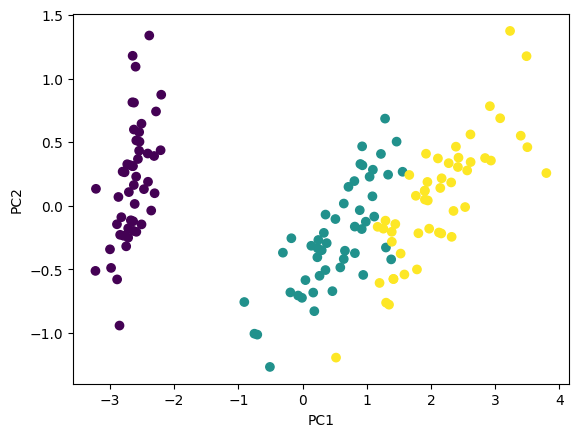

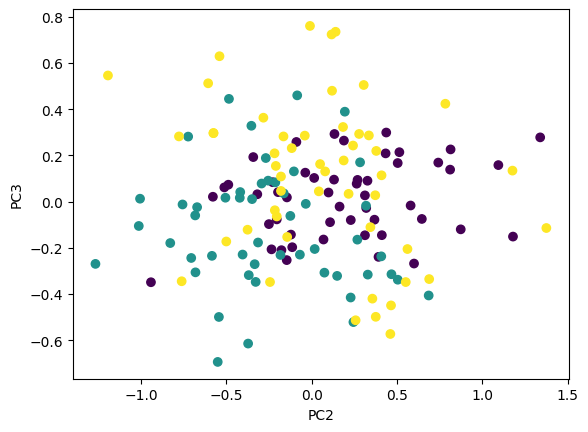

In [ ]:
from sklearn.decomposition import PCA
from sklearn.datasets import load_iris
import matplotlib.pyplot as plt

# Load Iris dataset
iris = load_iris()

# Let's say we want to reduce the data to two dimensions
pca = PCA(n_components=3)

# Fit and transform the data
iris_pca = pca.fit_transform(iris.data)

# Now we can plot the first two principal components
plt.scatter(iris_pca[:,0], iris_pca[:,1], c=iris.target)
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.show()

# Now we can plot the 2 and 3 principal components
plt.scatter(iris_pca[:,1], iris_pca[:,2], c=iris.target)
plt.xlabel('PC2')
plt.ylabel('PC3')
plt.show()

In [ ]:
iris_pca

array([[-2.68412563,  0.31939725, -0.02791483],
       [-2.71414169, -0.17700123, -0.21046427],
       [-2.88899057, -0.14494943,  0.01790026],
       [-2.74534286, -0.31829898,  0.03155937],
       [-2.72871654,  0.32675451,  0.09007924],
       [-2.28085963,  0.74133045,  0.16867766],
       [-2.82053775, -0.08946138,  0.25789216],
       [-2.62614497,  0.16338496, -0.02187932],
       [-2.88638273, -0.57831175,  0.02075957],
       [-2.6727558 , -0.11377425, -0.19763272],
       [-2.50694709,  0.6450689 , -0.07531801],
       [-2.61275523,  0.01472994,  0.10215026],
       [-2.78610927, -0.235112  , -0.20684443],
       [-3.22380374, -0.51139459,  0.06129967],
       [-2.64475039,  1.17876464, -0.15162752],
       [-2.38603903,  1.33806233,  0.2777769 ],
       [-2.62352788,  0.81067951,  0.13818323],
       [-2.64829671,  0.31184914,  0.02666832],
       [-2.19982032,  0.87283904, -0.12030552],
       [-2.5879864 ,  0.51356031,  0.21366517],
       [-2.31025622,  0.39134594, -0.239

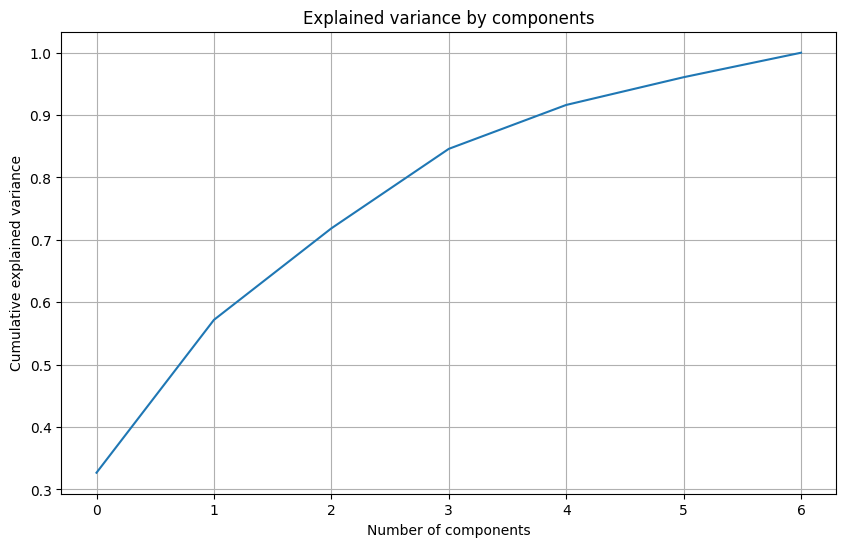

                 PC1       PC2       PC3  ...       PC5       PC6       PC7
total_bill  0.577289  0.133642  0.164816  ... -0.058183  0.378659  0.686390
tip         0.531650  0.178333  0.159316  ... -0.637807 -0.274214 -0.421978
sex         0.189111 -0.152571 -0.588523  ...  0.000506 -0.115541  0.007162
smoker      0.036649 -0.335732  0.724260  ...  0.212334  0.111732 -0.228151
day        -0.156579  0.660434 -0.047053  ...  0.003218  0.606759 -0.340735
time       -0.281249  0.556479  0.266919  ... -0.004329 -0.572115  0.352618
size        0.493317  0.261729 -0.055523  ...  0.738039 -0.245190 -0.241370

[7 rows x 7 columns]


In [ ]:
# IMPORT LIBRARIERS
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA

# LOAD THE DATA
tips = sns.load_dataset('tips')

# preprocessing
# encode categorical data

le = LabelEncoder()
cat_features = tips.select_dtypes(include='category').columns
for features in cat_features:
    tips[features] = le.fit_transform(tips[features])

# standardize the data
scaler = StandardScaler()
tips_scaled = scaler.fit_transform(tips)

# apply PCA
pca = PCA()
X_pca = pca.fit_transform(tips_scaled)

# plot the explained variance ratio
plt.figure(figsize=(10,6))
plt.plot(np.cumsum(pca.explained_variance_ratio_))
plt.xlabel('Number of components')
plt.ylabel('Cumulative explained variance')
plt.title('Explained variance by components')
plt.grid(True)
plt.show()

# Create a DataFrame to show the loadings
loadings = pd.DataFrame(pca.components_.T, columns=[f'PC{i+1}' for i in range(X_pca.shape[1])], index=tips.columns)

# Plot the loadings
print(loadings)



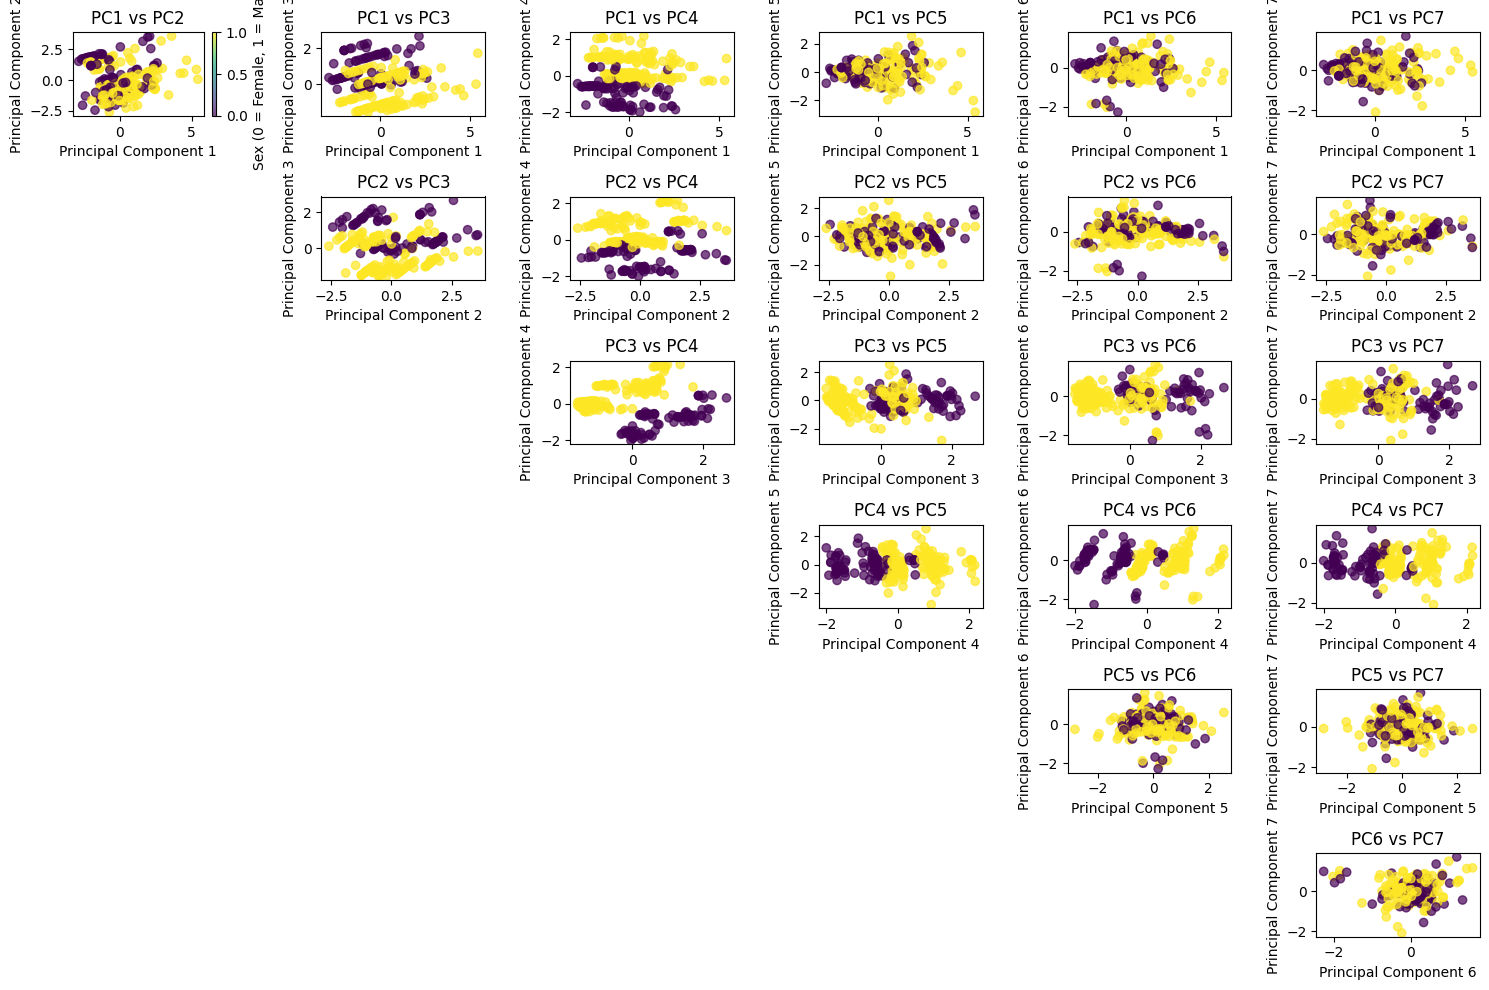

In [ ]:
n_components = X_pca.shape[1]

plt.figure(figsize=(15, 10))

for i in range(n_components):
    for j in range(i + 1, n_components):
        plt.subplot(n_components - 1, n_components - 1, i * (n_components - 1) + j)
        plt.scatter(X_pca[:, i], X_pca[:, j], c=tips['sex'], cmap='viridis', alpha=0.7)
        plt.xlabel(f'Principal Component {i+1}')
        plt.ylabel(f'Principal Component {j+1}')
        plt.title(f'PC{i+1} vs PC{j+1}')
        if i == 0 and j == 1: # Add colorbar only once
            plt.colorbar(label='Sex (0 = Female, 1 = Male)')
plt.tight_layout()
plt.show()

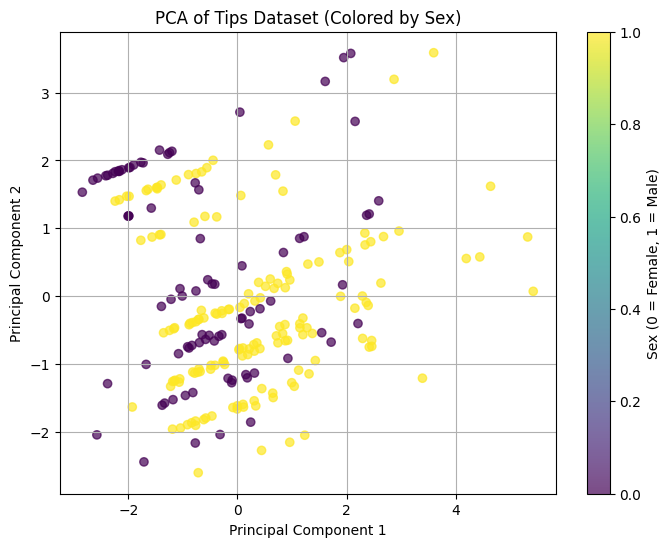

In [ ]:
plt.figure(figsize=(8, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=tips['sex'], cmap='viridis', alpha=0.7)
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('PCA of Tips Dataset (Colored by Sex)')
plt.colorbar(label='Sex (0 = Female, 1 = Male)')
plt.grid(True)
plt.show()

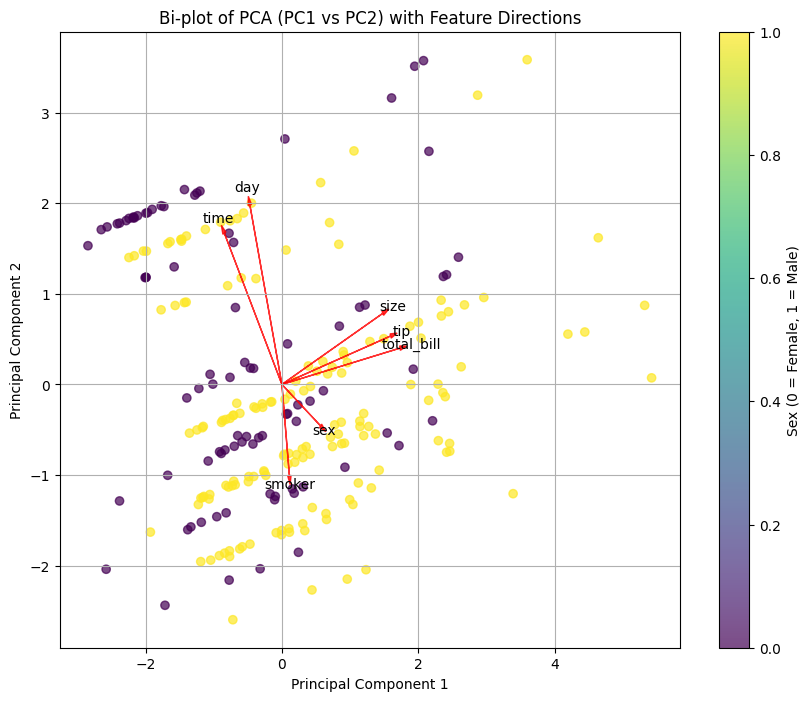

In [ ]:
plt.figure(figsize=(10, 8))

# Scatter plot of PC1 vs PC2, colored by sex
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=tips['sex'], cmap='viridis', alpha=0.7)
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('Bi-plot of PCA (PC1 vs PC2) with Feature Directions')
plt.colorbar(label='Sex (0 = Female, 1 = Male)')

# Plot feature directions (loadings)
# The 'loadings' DataFrame contains the coefficients for each feature on each principal component.
# We will scale these loadings for better visualization on the plot.

# Get the feature names
feature_names = tips.columns

# Scale the loadings for visualization purposes (e.g., by a factor)
# The scaling factor might need adjustment depending on the data spread
scaling_factor = 3.0 # You might need to adjust this value

for i, feature in enumerate(feature_names):
    # Plot arrow from origin to the loading value for PC1 and PC2
    plt.arrow(0, 0, loadings.loc[feature, 'PC1'] * scaling_factor, loadings.loc[feature, 'PC2'] * scaling_factor,
              color='r', alpha=0.8, head_width=0.05, head_length=0.1)
    # Annotate the feature name at the end of the arrow
    plt.text(loadings.loc[feature, 'PC1'] * scaling_factor * 1.1,
             loadings.loc[feature, 'PC2'] * scaling_factor * 1.1,
             feature, color='black', ha='center', va='center')

plt.grid(True)
plt.show()

In [ ]:
print('Explained variance ratio for each component:')
print(pca.explained_variance_ratio_)

Explained variance ratio for each component:
[0.32678897 0.24500246 0.14669421 0.12743089 0.07037688 0.04445825
 0.03924835]


### From the output of pca.explained_variance_ratio_, we see:

PC1 accounts for approximately 32.7% of the total variance.
PC2 accounts for approximately 24.5% of the total variance.
Together, PC1 and PC2 capture about 57.2% of the total variance in the tips dataset. This means that by just looking at these two principal components, we are retaining over half of the information (variability) present in the original seven features (total_bill, tip, sex, smoker, day, time, size). This is a significant dimensionality reduction from 7 features down to 2, without losing too much critical information.

Now, let's interpret the bi-plot we generated (PC1 vs PC2 with feature directions):

Interpretation of PC1: Looking at the loadings DataFrame and the arrows on the bi-plot, features like total_bill, tip, and size have strong positive loadings on PC1. This suggests that PC1 primarily captures the overall magnitude of the dining experience. A higher value on PC1 would likely indicate a larger bill, a larger tip, and a larger dining party.

Interpretation of PC2: Features like day and time have significant positive loadings on PC2, while smoker has a negative loading. This indicates that PC2 differentiates observations based on the day of the week or time of the day, and also by whether the customer was a smoker or not. For example, a high PC2 value might be associated with dining on specific days or times, and being a non-smoker, while a low PC2 value might be related to other days/times and being a smoker.

Visual Insights from the Scatter Plot (PC1 vs PC2, colored by Sex): Even though sex has relatively lower loadings on PC1 and PC2 compared to other features, the scatter plot allows us to visually inspect if there's any clustering or separation between genders along these dominant dimensions. While the separation might not be extremely clear cut, if groups were distinct, we would see them cluster in different regions of the PC1-PC2 plane.

In summary, PC1 and PC2 are crucial because they distill the most important patterns from your complex, multi-dimensional data into a simple 2D view. This allows us to:

Visualize the data's inherent structure that would be impossible with 7 original features.
Identify which original features contribute most to the major variations in the data.
Reduce the data's complexity significantly while preserving most of its information, which can be useful for further analysis or machine learning tasks.

In [ ]:
print('Eigenvalues (Explained Variance) for each component:')
print(pca.explained_variance_)

Eigenvalues (Explained Variance) for each component:
[2.29693645 1.72207492 1.03108524 0.89568705 0.49466546 0.31248841
 0.27586904]


### Eigenvalues are a fundamental concept in linear algebra and are crucial for Principal Component Analysis (PCA). They represent the magnitude of the variance along each principal component.

Here's how they are generally calculated in the context of PCA:

Start with the Covariance Matrix: First, you compute the covariance matrix (let's call it 'A') of your standardized dataset. This matrix describes how each pair of variables in your data varies together.

The Eigenvalue Equation: Eigenvalues (often denoted by the Greek letter lambda, (\lambda)) and eigenvectors (often denoted by 'v') are found by solving the eigenvalue equation: (Av = \lambda v) Where:

A is the covariance matrix of your data.
v is an eigenvector.
\(\lambda\) is an eigenvalue.
This equation essentially states that when the covariance matrix A transforms an eigenvector v, the result is simply a scaled version of v by a factor of \(\lambda\).

Rearranging the Equation: To solve for (\lambda) and v, the equation is typically rearranged: (Av - \lambda v = 0) (Av - \lambda Iv = 0) (where I is the identity matrix, allowing for matrix subtraction) ((A - \lambda I)v = 0)

Finding Non-Trivial Solutions: For v to be a non-zero eigenvector (a 'non-trivial' solution), the matrix ((A - \lambda I)) must be singular, meaning its determinant must be zero: (det(A - \lambda I) = 0)

Solving the Characteristic Equation: This equation is called the characteristic equation. Solving this polynomial equation for (\lambda) will give you the eigenvalues. For an n x n covariance matrix, you will typically find n eigenvalues. Each eigenvalue corresponds to a principal component and represents the amount of variance explained by that principal component.

In PCA, these eigenvalues are then ordered from largest to smallest, and the corresponding eigenvectors become the principal components. The larger the eigenvalue, the more variance that principal component captures, and thus the more important it is in representing the data's structure.

In [ ]:
print('\nEigenvectors (Principal Components) as rows:')
print(pca.components_)


Eigenvectors (Principal Components) as rows:
[[ 5.77289165e-01  5.31649983e-01  1.89110665e-01  3.66487360e-02
  -1.56579121e-01 -2.81249345e-01  4.93316659e-01]
 [ 1.33641969e-01  1.78333496e-01 -1.52570802e-01 -3.35731699e-01
   6.60433548e-01  5.56478939e-01  2.61729027e-01]
 [ 1.64816231e-01  1.59315569e-01 -5.88523024e-01  7.24259708e-01
  -4.70525528e-02  2.66919302e-01 -5.55232314e-02]
 [ 6.17564321e-02 -1.03752795e-02  7.62363861e-01  5.01763369e-01
   2.29846129e-01  2.97170223e-01 -1.48236220e-01]
 [-5.81827578e-02 -6.37806858e-01  5.05574660e-04  2.12333968e-01
   3.21804280e-03 -4.32947948e-03  7.38039368e-01]
 [ 3.78659164e-01 -2.74213734e-01 -1.15541136e-01  1.11732240e-01
   6.06758906e-01 -5.72115258e-01 -2.45189682e-01]
 [ 6.86389686e-01 -4.21978201e-01  7.16171143e-03 -2.28150578e-01
  -3.40735376e-01  3.52617822e-01 -2.41370453e-01]]


### What are Eigenvectors in PCA?
In PCA, eigenvectors are the directions or axes along which the data varies the most. They are also known as the principal components. Each eigenvector represents a new dimension that is a linear combination of the original features, and they are orthogonal (perpendicular) to each other, meaning they capture independent directions of variance.

When we performed PCA on the tips dataset, the pca.components_ attribute gives us these eigenvectors. Each row in pca.components_ corresponds to one principal component, and the values in that row are the 'loadings' (coefficients) of the original features for that principal component. These loadings tell us how much each original feature contributes to that specific principal component.

Let's look at the eigenvectors we printed:

In [ ]:
print(pca.components_)

[[ 5.77289165e-01  5.31649983e-01  1.89110665e-01  3.66487360e-02
  -1.56579121e-01 -2.81249345e-01  4.93316659e-01]
 [ 1.33641969e-01  1.78333496e-01 -1.52570802e-01 -3.35731699e-01
   6.60433548e-01  5.56478939e-01  2.61729027e-01]
 [ 1.64816231e-01  1.59315569e-01 -5.88523024e-01  7.24259708e-01
  -4.70525528e-02  2.66919302e-01 -5.55232314e-02]
 [ 6.17564321e-02 -1.03752795e-02  7.62363861e-01  5.01763369e-01
   2.29846129e-01  2.97170223e-01 -1.48236220e-01]
 [-5.81827578e-02 -6.37806858e-01  5.05574660e-04  2.12333968e-01
   3.21804280e-03 -4.32947948e-03  7.38039368e-01]
 [ 3.78659164e-01 -2.74213734e-01 -1.15541136e-01  1.11732240e-01
   6.06758906e-01 -5.72115258e-01 -2.45189682e-01]
 [ 6.86389686e-01 -4.21978201e-01  7.16171143e-03 -2.28150578e-01
  -3.40735376e-01  3.52617822e-01 -2.41370453e-01]]


### Interpretation of Eigenvectors (Principal Components) for tips dataset:
We can relate these values to our loadings DataFrame, which gives a clearer picture with feature names:

In [ ]:
print('All Principal Components (X_pca):')
print(X_pca)

All Principal Components (X_pca):
[[-1.39500701 -0.14903418 -0.20479497 ...  0.33002593  1.0153699
   0.39161019]
 [-0.66228816 -0.20789918 -1.54035959 ...  0.85197064  0.1033027
  -0.56016175]
 [ 0.73950088  0.1902471  -1.1301151  ... -0.0678242   0.19267163
  -0.29810894]
 ...
 [-0.00517402 -1.65958763  0.32824512 ...  0.27031073  0.39367739
   0.44148197]
 [-0.49204338 -1.0735558  -1.28183836 ... -0.01964779  0.00655036
   0.61293775]
 [-0.68177336  0.84895414  0.00714481 ... -0.59742072  1.35248468
  -0.44664352]]


### First Principal Component (PC1 - the first eigenvector):

Its values are in the 'PC1' column of the loadings DataFrame (or the first row of pca.components_).
Notice the high positive values for total_bill (0.577), tip (0.531), and size (0.493).
This indicates that PC1 is primarily driven by these three features. It essentially represents the overall 'largeness' or 'expense' of the dining experience. If a data point has a high PC1 score, it means it's likely a large bill, a good tip, and/or a large dining party.
Second Principal Component (PC2 - the second eigenvector):

Its values are in the 'PC2' column (or the second row of pca.components_).
It has high positive values for day (0.660) and time (0.556), and a moderate negative value for smoker (-0.335).
This suggests that PC2 differentiates observations based on the day and time of the week, and whether the customer is a smoker. For instance, a high PC2 score might correspond to dining on specific days/times and being a non-smoker, while a low PC2 score might be associated with other day/time combinations and being a smoker.
In summary, these eigenvectors (principal components) give us a way to understand the underlying structure of our data. By examining the loadings, we can see which original features contribute most to each principal component, allowing us to interpret what each new, reduced dimension actually represents in the context of our data.

###  scree plot visualizes the eigenvalues (explained variance) for each principal component, ordered from largest to smallest. This helps to determine the 'elbow' point, indicating the number of components that capture most of the variance.

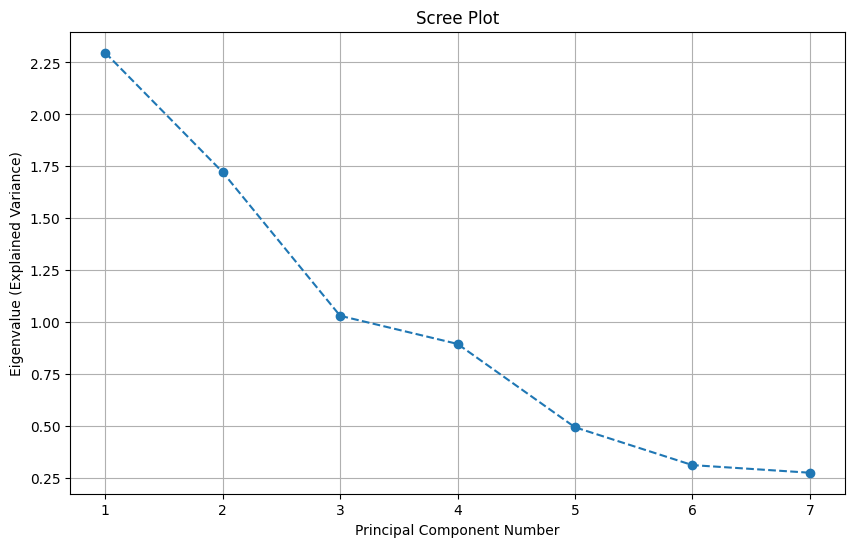

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(pca.explained_variance_) + 1), pca.explained_variance_, marker='o', linestyle='--')
plt.xlabel('Principal Component Number')
plt.ylabel('Eigenvalue (Explained Variance)')
plt.title('Scree Plot')
plt.grid(True)
plt.show()

### Loading Scores Explained

**What are Loading Scores?**
Loading scores, often simply called "loadings," represent the correlation between the original variables (features) and the principal components. They indicate how much each original feature contributes to or is associated with each principal component. A high absolute loading score (positive or negative) for a feature on a specific principal component means that feature has a strong influence on that component.

**How are Loading Scores Calculated?**
Loading scores are derived directly from the **eigenvectors** of the covariance matrix (or correlation matrix if the data was scaled) of your standardized dataset. When you perform Principal Component Analysis (PCA), the algorithm finds these eigenvectors, which are the principal components themselves.

In `sklearn.decomposition.PCA`, these eigenvectors are stored in the `pca.components_` attribute. Each row of `pca.components_` is a principal component, and the values within that row are the loading scores for each of the original features on that specific principal component. We previously created a `loadings` DataFrame to make this interpretation clearer.

Let's print the `loadings` DataFrame again for reference:

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA

# Re-load and preprocess data to ensure variables are available if cell is run independently
tips = sns.load_dataset('tips')
le = LabelEncoder()
cat_features = tips.select_dtypes(include='category').columns
for feature in cat_features:
    tips[feature] = le.fit_transform(tips[feature])
scaler = StandardScaler()
tips_scaled = scaler.fit_transform(tips)
pca = PCA()
X_pca = pca.fit_transform(tips_scaled)
loadings = pd.DataFrame(pca.components_.T, columns=[f'PC{i+1}' for i in range(X_pca.shape[1])], index=tips.columns)

print(loadings)

                 PC1       PC2       PC3       PC4       PC5       PC6  \
total_bill  0.577289  0.133642  0.164816  0.061756 -0.058183  0.378659   
tip         0.531650  0.178333  0.159316 -0.010375 -0.637807 -0.274214   
sex         0.189111 -0.152571 -0.588523  0.762364  0.000506 -0.115541   
smoker      0.036649 -0.335732  0.724260  0.501763  0.212334  0.111732   
day        -0.156579  0.660434 -0.047053  0.229846  0.003218  0.606759   
time       -0.281249  0.556479  0.266919  0.297170 -0.004329 -0.572115   
size        0.493317  0.261729 -0.055523 -0.148236  0.738039 -0.245190   

                 PC7  
total_bill  0.686390  
tip        -0.421978  
sex         0.007162  
smoker     -0.228151  
day        -0.340735  
time        0.352618  
size       -0.241370  


**Interpretation for the Tips Dataset:**
Based on the `loadings` DataFrame:

*   **PC1 (First Principal Component):**
    *   Features with high positive loadings on PC1 include `total_bill` (0.577), `tip` (0.532), and `size` (0.493). This indicates that PC1 primarily captures the overall 'largeness' or 'expense' of the dining experience. A higher PC1 value suggests a larger bill, tip, and dining party.
*   **PC2 (Second Principal Component):**
    *   Features like `day` (0.660) and `time` (0.556) have significant positive loadings on PC2, while `smoker` (-0.336) has a moderate negative loading. PC2 seems to distinguish observations based on the day of the week, time of day, and whether the customer is a smoker. For instance, a high PC2 might be associated with specific days/times and non-smokers.

**Plotting Loading Scores (Bi-plot):**
A bi-plot is an excellent way to visualize both the data points projected onto the principal components and the loading scores (as vectors) of the original features simultaneously. The direction and length of the arrows from the origin indicate how each original feature contributes to the principal components shown in the plot. The longer the arrow, the stronger the influence of that feature.
""")

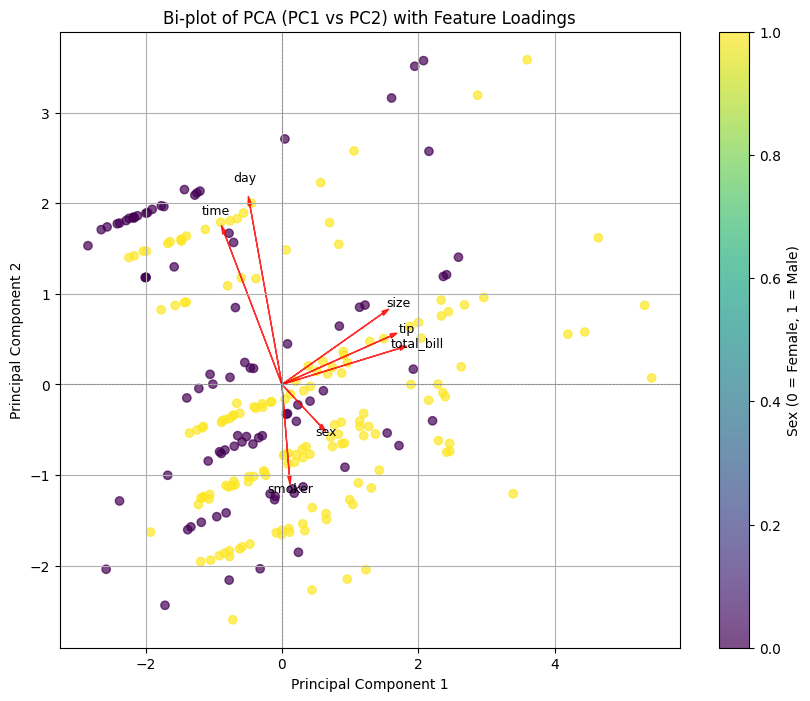


This bi-plot visually confirms the interpretations from the loading scores: features like 'total_bill', 'tip', and 'size' point in a similar direction as PC1 (positive x-axis), while 'day' and 'time' point towards the positive y-axis (PC2).


In [ ]:
# --- Bi-plot Code ---
plt.figure(figsize=(10, 8))

# Scatter plot of PC1 vs PC2, colored by sex
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=tips['sex'], cmap='viridis', alpha=0.7)
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('Bi-plot of PCA (PC1 vs PC2) with Feature Loadings')
plt.colorbar(label='Sex (0 = Female, 1 = Male)')

# Plot feature directions (loadings)
feature_names = tips.columns
# Scaling factor for loadings to make arrows visible and proportional to data spread
# Adjust this value if arrows are too small or too large relative to scatter points
scaling_factor = 3.0

for i, feature in enumerate(feature_names):
    # Plot arrow from origin to the loading value for PC1 and PC2
    plt.arrow(0, 0, loadings.loc[feature, 'PC1'] * scaling_factor, loadings.loc[feature, 'PC2'] * scaling_factor,
              color='r', alpha=0.8, head_width=0.05, head_length=0.1)
    # Annotate the feature name at the end of the arrow
    plt.text(loadings.loc[feature, 'PC1'] * scaling_factor * 1.15, # slight offset for text
             loadings.loc[feature, 'PC2'] * scaling_factor * 1.15, # slight offset for text
             feature, color='black', ha='center', va='center', fontsize=9)

plt.grid(True)
plt.axhline(0, color='gray', linestyle='--', linewidth=0.5)
plt.axvline(0, color='gray', linestyle='--', linewidth=0.5)
plt.show()

print("\nThis bi-plot visually confirms the interpretations from the loading scores: features like 'total_bill', 'tip', and 'size' point in a similar direction as PC1 (positive x-axis), while 'day' and 'time' point towards the positive y-axis (PC2).")